In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Tuple, Callable, Optional
from cvxopt import matrix, solvers
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
def linear_kernel(x1: np.ndarray, x2: np.ndarray) -> float:
    """定义一个线性核函数

    Args:
        x1 (np.ndarray): 向量1，形状通常为 (n,)
        x2 (np.ndarray): 向量2，形状通常为 (n,)

    Returns:
        float: 两个向量的点乘结果
    """
    return x1 @ x2


## cvxopt的公式

目标函数：$\min \frac{1}{2} x^T P x + q^T x$ （对应参数 P, q）

不等式约束：$Gx \le h$ （对应参数 G, h）

等式约束：$Ax = b$ （对应参数 A, b）

## 软间隔的对偶函数

目标函数：
$$\min_{\alpha} \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N \alpha_i \alpha_j y_i y_j (x_i \cdot x_j) - \sum_{i=1}^N \alpha_i$$

不等式约束：
$$
0\leq \alpha_{i} \leq C
$$

等式约束：
$$
\sum_{i=1}^N\alpha_{i} y_i = 0
$$

## $alpha$ 反推 $b$

根据 KKT 条件的数学推导，对于任何一个恰好满足 $0 < \alpha_k < C$ 的支持向量 $(x_k, y_k)$，它不偏不倚，刚刚好踩在安全隔离带的边界上。这就意味着，对于这个点，分类间隔的等式是严格成立的：
$$y_k(w \cdot x_k + b) = 1$$

根据上面的式子，可得

$$
b=\frac{1-y_{k} \cdot w \cdot x_{k}}{y_{k}}
$$

由于$y_k$的值只能为 1 或者 -1，所以$y_k=\frac{1}{y_{k}}$，由此得到：
$$b = y_k - w \cdot x_k$$

根据求$w$的式子$w = \sum_{i=1}^N \alpha_i y_i x_i$，利用核技巧将$w \cdot x_k$直接替换成另一种形式：
$$w \cdot x_k = \sum_{i=1}^{N_{spv}} \alpha_i y_i K(x_i, x_k)$$

最终得到求截距 b 的核函数版本的公式为：
$$b = y_k - \sum_{i=1}^{N_{spv}} \alpha_i y_i K(x_i, x_k)$$

In [3]:
class Soft_Margin_SVM:
    """定义近似线性可分支持向量机类 (软间隔最大化策略)"""

    def __init__(self, kernel: Callable = linear_kernel, C: Optional[float] = None):
        """定义基本参数 [cite: 432]

        Args:
            kernel (Callable): SVM 核函数，默认为线性核函数 linear_kernel 
            C (Optional[float]): 惩罚参数。如果为 None，则退化为硬间隔；如果有值，则为软间隔 [cite: 436, 438]
        """
        self.kernel = kernel
        self.C = float(C) if C is not None else None
        self.w = None
        self.b = None
        self.alpha = None      # 支持向量对应的拉格朗日乘子 alpha
        self.spv_X = None    # 支持向量的特征 X
        self.spv_y = None    # 支持向量的标签 y

    def _gram_matrix(self, X: np.ndarray) -> np.ndarray:
        """定义 Gram 矩阵的计算函数 [cite: 488]

        Args:
            X (np.ndarray): 输入特征数据，形状为 (m, n)

        Returns:
            np.ndarray: Gram 矩阵，形状为 (m, m)，其中 K[i, j] = kernel(X[i], X[j])
        """
        m, n = X.shape
        K = np.zeros((m, m))
        # 遍历计算Gram矩阵
        for i in range(m):
            for j in range(m):
                K[i,j] = self.kernel(X[i], X[j])
        return K

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """定义线性可分支持向量机拟合方法

        Args:
            X (np.ndarray): 训练特征数据，形状为 (m, n)
            y (np.ndarray): 训练输出标签，形状为 (m,)
        """
        m = X.shape[0]
        n = X.shape[1]
        y_T = y.reshape(-1, 1)
        # 1: 调用 self._gram_matrix(X) 计算 Gram 矩阵 K
        K = self._gram_matrix(X)
        # 2: 二次规划相关变量: P, q, A, b (注意此处的 b 是等式约束，非截距)
        P = matrix(y_T @ y.reshape(1, -1) * K)
        q = matrix(-np.ones(m))
        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)
        # 3: 根据 self.C 是否为 None，分别构造不等式约束矩阵 G 和 h
        G = -np.identity(m)
        h = np.zeros(m)
        if self.C is None:
            G = matrix(G)
            h = matrix(h)
        else:
            G = matrix(np.vstack((G, np.identity(m))))
            h = matrix(np.hstack((h, np.full(m, self.C))))
        # 4: 构建二次规划求解器 solvers.qp，并提取拉格朗日乘子 alpha
        sol = solvers.qp(P, q, G, h, A, b)
        alpha = np.ravel(sol['x'])
        # 5: 寻找大于 1e-5 的 alpha 作为支持向量，并保存到 self.a, self.spv, self.spv_y
        is_support_vector = alpha > 1e-5
        spv_index = np.arange(len(alpha))[is_support_vector]
        self.alpha = alpha[spv_index]
        self.spv_X = X[spv_index]
        self.spv_y = y[spv_index]
        # 6: 计算截距 self.b 和 权重 self.w
        self.w = X[spv_index].T @ (alpha[spv_index] * y[spv_index])

        b_list = []
        for i in range(len(self.alpha)):
            b_i = self.spv_y[i] - np.sum(self.alpha * self.spv_y * K[spv_index[i], is_support_vector])
            b_list.append(b_i)

        self.b = np.mean(b_list)

    def project(self, X: np.ndarray) -> np.ndarray:
        """定义模型映射函数，计算 wx + b 的值

        Args:
            X (np.ndarray): 输入特征数据，形状为 (m_test, n)

        Returns:
            np.ndarray: 线性映射结果
        """
        if self.w is not None:
            return self.w @ X.T + self.b

    def predict(self, X: np.ndarray) -> np.ndarray:
        """定义模型预测函数

        Args:
            X (np.ndarray): 测试特征数据，形状为 (m_test, n)

        Returns:
            np.ndarray: 预测标签，包含 1 或 -1
        """
        return np.sign(self.w @ X.T + self.b)

In [4]:
mean1, mean2 = np.array([0, 2]), np.array([2, 0])
covar = np.array([[1.5, 1.0], [1.0, 1.5]])
X1 = np.random.multivariate_normal(mean1, covar, 100)
y1 = np.ones(X1.shape[0])
X2 = np.random.multivariate_normal(mean2, covar, 100)
y2 = -1 * np.ones(X2.shape[0])
X_train = np.vstack((X1[:80], X2[:80]))
y_train = np.hstack((y1[:80], y2[:80]))
X_test = np.vstack((X1[80:], X2[80:]))
y_test = np.hstack((y1[80:], y2[80:]))
print(f'X_train: {X_train.shape}\n' \
      f'y_train: {y_train.shape}\n' \
      f'X_test: {X_test.shape}\n' \
      f'y_test: {y_test.shape}')

X_train: (160, 2)
y_train: (160,)
X_test: (40, 2)
y_test: (40,)


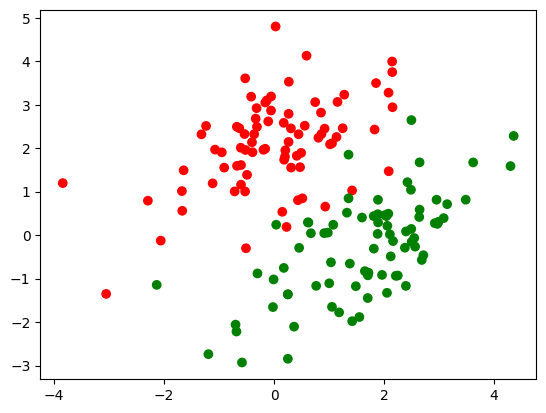

In [5]:
# 设置颜色参数
colors = {1:'r', -1:'g'}
# 绘制二分类数据集的散点图
plt.scatter(X_train[:,0], X_train[:,1], marker='o', c=pd.Series(y_train).map(colors))
plt.show();

In [6]:
SMS = Soft_Margin_SVM(C=0.1)
SMS.fit(X_train, y_train)
y_pred = SMS.predict(X_test)

     pcost       dcost       gap    pres   dres
 0: -1.8660e+01 -2.7129e+01  8e+02  2e+01  7e-15
 1: -3.5698e+00 -2.4772e+01  6e+01  1e+00  9e-15
 2: -2.0966e+00 -1.0307e+01  1e+01  8e-02  2e-15
 3: -2.1786e+00 -3.4759e+00  1e+00  1e-02  1e-15
 4: -2.3968e+00 -2.8424e+00  5e-01  3e-03  1e-15
 5: -2.4797e+00 -2.6530e+00  2e-01  9e-04  1e-15
 6: -2.5275e+00 -2.5564e+00  3e-02  5e-05  1e-15
 7: -2.5362e+00 -2.5447e+00  9e-03  1e-05  1e-15
 8: -2.5393e+00 -2.5402e+00  9e-04  3e-07  1e-15
 9: -2.5397e+00 -2.5397e+00  9e-06  3e-09  1e-15
10: -2.5397e+00 -2.5397e+00  9e-08  3e-11  1e-15
Optimal solution found.


In [7]:
print('Accuracy of soft margin svm based on cvxopt: ',
      accuracy_score(y_test, y_pred))

Accuracy of soft margin svm based on cvxopt:  1.0


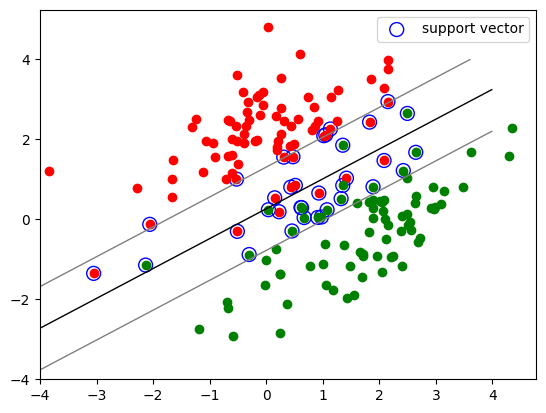

In [8]:
def plot_classifier(X1_train, X2_train, clf):
    plt.plot(X1_train[:,0], X1_train[:,1], "ro")
    plt.plot(X2_train[:,0], X2_train[:,1], "go")
    
    # 这里将 c="" 改为了 c="none"
    plt.scatter(clf.spv_X[:,0], clf.spv_X[:,1],
                s=100, c="none", edgecolors="b", label="support vector")

    X1, X2 = np.meshgrid(np.linspace(-4,4,50), np.linspace(-4,4,50))
    X = np.array([[x1, x2] for x1, x2 in zip(np.ravel(X1), np.ravel(X2))])
    Z = clf.project(X).reshape(X1.shape)
    
    plt.contour(X1, X2, Z, [0.0], colors='k', linewidths=1, origin='lower')
    plt.contour(X1, X2, Z + 1, [0.0], colors='grey', linewidths=1, origin='lower')
    plt.contour(X1, X2, Z - 1, [0.0], colors='grey', linewidths=1, origin='lower')
    plt.legend()
    plt.show()

plot_classifier(X_train[y_train==1], X_train[y_train==-1], SMS)